Working directory: /Users/niaracheva/Desktop/aircraft-engine-predictive-maintenance
Data files: ['train_FD001.txt', 'RUL_FD001.txt', 'test_FD001.txt']
Dataset shape: (20631, 26)

First few rows:
   engine_id  cycle  setting1  setting2  setting3  sensor1  sensor2  sensor3  \
0        1.0    1.0   -0.0007   -0.0004     100.0   518.67   641.82  1589.70   
1        1.0    2.0    0.0019   -0.0003     100.0   518.67   642.15  1591.82   
2        1.0    3.0   -0.0043    0.0003     100.0   518.67   642.35  1587.99   
3        1.0    4.0    0.0007    0.0000     100.0   518.67   642.35  1582.79   
4        1.0    5.0   -0.0019   -0.0002     100.0   518.67   642.37  1582.85   
5        1.0    6.0   -0.0043   -0.0001     100.0   518.67   642.10  1584.47   
6        1.0    7.0    0.0010    0.0001     100.0   518.67   642.48  1592.32   
7        1.0    8.0   -0.0034    0.0003     100.0   518.67   642.56  1582.96   
8        1.0    9.0    0.0008    0.0001     100.0   518.67   642.12  1590.98   
9    

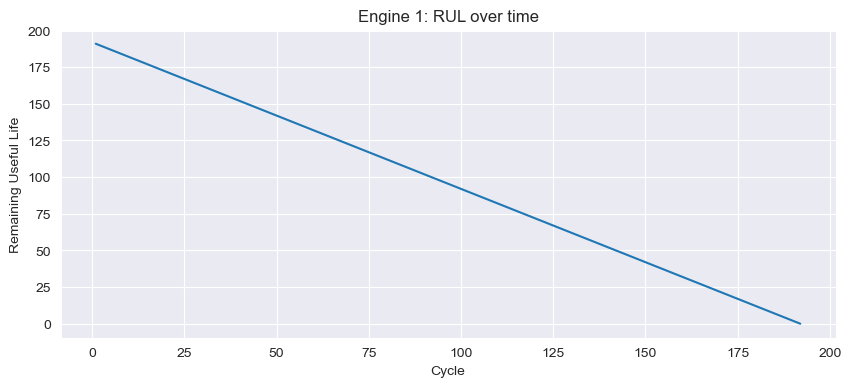


First few rows with RUL:
    engine_id  cycle  max_cycle    RUL
0         1.0    1.0      192.0  191.0
1         1.0    2.0      192.0  190.0
2         1.0    3.0      192.0  189.0
3         1.0    4.0      192.0  188.0
4         1.0    5.0      192.0  187.0
5         1.0    6.0      192.0  186.0
6         1.0    7.0      192.0  185.0
7         1.0    8.0      192.0  184.0
8         1.0    9.0      192.0  183.0
9         1.0   10.0      192.0  182.0
10        1.0   11.0      192.0  181.0
11        1.0   12.0      192.0  180.0
12        1.0   13.0      192.0  179.0
13        1.0   14.0      192.0  178.0
14        1.0   15.0      192.0  177.0


<Figure size 640x480 with 0 Axes>

In [2]:
import os
os.chdir('/Users/niaracheva/Desktop/aircraft-engine-predictive-maintenance')
print("Working directory:", os.getcwd())
print("Data files:", os.listdir('data'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

# Column names (dataset doesn't have headers)
column_names = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + \
               [f'sensor{i}' for i in range(1, 22)]

# Load training data with explicit dtype
train_df = pd.read_csv('data/train_FD001.txt', 
                       sep=r'\s+',  # Use regex for multiple spaces
                       header=None, 
                       names=column_names,
                       dtype=np.float64,
                       na_values='NA')

print("Dataset shape:", train_df.shape)
print("\nFirst few rows:")
print(train_df.head(10))

print("\nBasic stats:")
print(train_df.describe())




# Calculate Remaining Useful Life (RUL) for each reading
# RUL = max_cycle - current_cycle for each engine

# Get max cycle for each engine (when it failed)
max_cycles = train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycles.columns = ['engine_id', 'max_cycle']

# Merge back to get max_cycle for each row
train_df = train_df.merge(max_cycles, on='engine_id', how='left')

# Calculate RUL
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']

print("\nRUL distribution:")
print(train_df['RUL'].describe())

# Visualize RUL for one engine
engine_1 = train_df[train_df['engine_id'] == 1]
plt.figure(figsize=(10, 4))
plt.plot(engine_1['cycle'], engine_1['RUL'])
plt.xlabel('Cycle')
plt.ylabel('Remaining Useful Life')
plt.title('Engine 1: RUL over time')
plt.grid(True)
plt.show()

print("\nFirst few rows with RUL:")
print(train_df[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(15))


plt.savefig('visualizations/plot_name.png', dpi=300, bbox_inches='tight')


In [3]:
#which sensors vary vs which are constant
print("Checking which sensors actually change...")
for col in train_df.columns:
    if col.startswith('sensor'):
        unique_vals = train_df[col].nunique()
        print(f"{col}: {unique_vals} unique values")


Checking which sensors actually change...
sensor1: 1 unique values
sensor2: 310 unique values
sensor3: 3012 unique values
sensor4: 4051 unique values
sensor5: 1 unique values
sensor6: 2 unique values
sensor7: 513 unique values
sensor8: 53 unique values
sensor9: 6403 unique values
sensor10: 1 unique values
sensor11: 159 unique values
sensor12: 427 unique values
sensor13: 56 unique values
sensor14: 6078 unique values
sensor15: 1918 unique values
sensor16: 1 unique values
sensor17: 13 unique values
sensor18: 1 unique values
sensor19: 1 unique values
sensor20: 120 unique values
sensor21: 4745 unique values


------------------------------------------------------------------------------------------------------------------------
COMPARING HEALTHY VS FAILING ENGINES
------------------------------------------------------------------------------------------------------------------------

SENSOR3:
  Healthy engines (RUL>150): mean = 1586.92
  Failing engines (RUL<30):  mean = 1598.81
  DIFFERENCE: 11.89

SENSOR4:
  Healthy engines (RUL>150): mean = 1402.68
  Failing engines (RUL<30):  mean = 1422.96
  DIFFERENCE: 20.28

SENSOR11:
  Healthy engines (RUL>150): mean = 47.35
  Failing engines (RUL<30):  mean = 47.97
  DIFFERENCE: 0.62

SENSOR15:
  Healthy engines (RUL>150): mean = 8.42
  Failing engines (RUL<30):  mean = 8.50
  DIFFERENCE: 0.08

SENSOR21:
  Healthy engines (RUL>150): mean = 23.36
  Failing engines (RUL<30):  mean = 23.13
  DIFFERENCE: 0.23


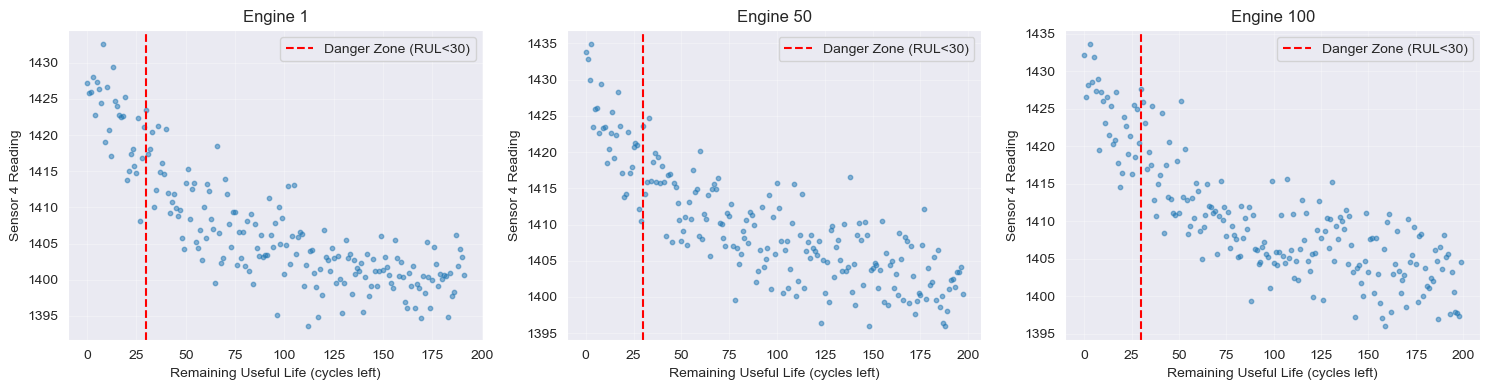

<Figure size 640x480 with 0 Axes>

In [4]:
interesting_sensors = ['sensor3', 'sensor4', 'sensor11', 'sensor15', 'sensor21']

# Healthy: RUL > 150 cycles left
healthy = train_df[train_df['RUL'] > 150]

# Failing: RUL < 30 cycles left (danger zone!)
failing = train_df[train_df['RUL'] < 30]

print("--" * 60)
print("COMPARING HEALTHY VS FAILING ENGINES")
print("--" * 60)

for sensor in interesting_sensors:
    print(f"\n{sensor.upper()}:")
    print(f"  Healthy engines (RUL>150): mean = {healthy[sensor].mean():.2f}")
    print(f"  Failing engines (RUL<30):  mean = {failing[sensor].mean():.2f}")
    print(f"  DIFFERENCE: {abs(healthy[sensor].mean() - failing[sensor].mean()):.2f}")


#sensor4 over time for 3 different engines
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, engine_num in enumerate([1, 50, 100]):
    engine_data = train_df[train_df['engine_id'] == engine_num]
    
    axes[i].scatter(engine_data['RUL'], engine_data['sensor4'], alpha=0.5, s=10)
    axes[i].set_xlabel('Remaining Useful Life (cycles left)')
    axes[i].set_ylabel('Sensor 4 Reading')
    axes[i].set_title(f'Engine {engine_num}')
    axes[i].grid(True, alpha=0.3)
    axes[i].axvline(x=30, color='red', linestyle='--', label='Danger Zone (RUL<30)')
    axes[i].legend()

plt.tight_layout()
plt.show()
plt.savefig('visualizations/plot_name.png', dpi=300, bbox_inches='tight')



Class distribution:
will_fail_soon
0    17531
1     3100
Name: count, dtype: int64

Percentage:
will_fail_soon
0    84.974068
1    15.025932
Name: proportion, dtype: float64


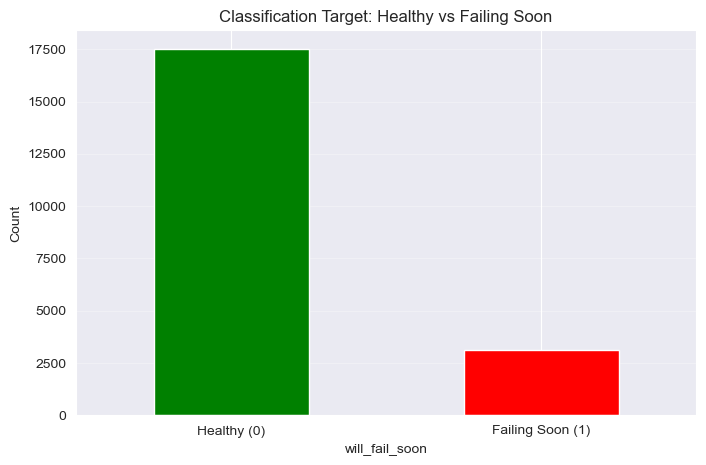

<Figure size 640x480 with 0 Axes>

In [5]:
# Based on YOUR investigation, we'll use 30 cycles as the threshold
threshold = 30

# Create binary labels
train_df['will_fail_soon'] = (train_df['RUL'] <= threshold).astype(int)

print("Class distribution:")
print(train_df['will_fail_soon'].value_counts())
print("\nPercentage:")
print(train_df['will_fail_soon'].value_counts(normalize=True) * 100)

# Visualize the split
plt.figure(figsize=(8, 5))
train_df['will_fail_soon'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.xticks([0, 1], ['Healthy (0)', 'Failing Soon (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Classification Target: Healthy vs Failing Soon')
plt.grid(axis='y', alpha=0.3)
plt.show()
plt.savefig('visualizations/plot_name.png', dpi=300, bbox_inches='tight')


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

X = train_df[['sensor3', 'sensor4']]
y = train_df['will_fail_soon']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"\nTraining set distribution:")
print(y_train.value_counts())

model = RandomForestClassifier(
    n_estimators=100,         
    class_weight='balanced',    
    random_state=42,
    max_depth=10,
    n_jobs=-1                 
)

print("Training model on sensor3 + sensor4...")
model.fit(X_train, y_train)
print("Model trained!")

y_pred = model.predict(X_test)

print("\n" + "--"*60)
print("MODEL PERFORMANCE")
print("--"*60)
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Failing Soon']))
plt.savefig('visualizations/plot_name.png', dpi=300, bbox_inches='tight')


Training samples: 16504
Test samples: 4127

Training set distribution:
will_fail_soon
0    14024
1     2480
Name: count, dtype: int64
Training model on sensor3 + sensor4...
Model trained!

------------------------------------------------------------------------------------------------------------------------
MODEL PERFORMANCE
------------------------------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

     Healthy       0.98      0.92      0.95      3507
Failing Soon       0.68      0.89      0.77       620

    accuracy                           0.92      4127
   macro avg       0.83      0.91      0.86      4127
weighted avg       0.93      0.92      0.92      4127



<Figure size 640x480 with 0 Axes>

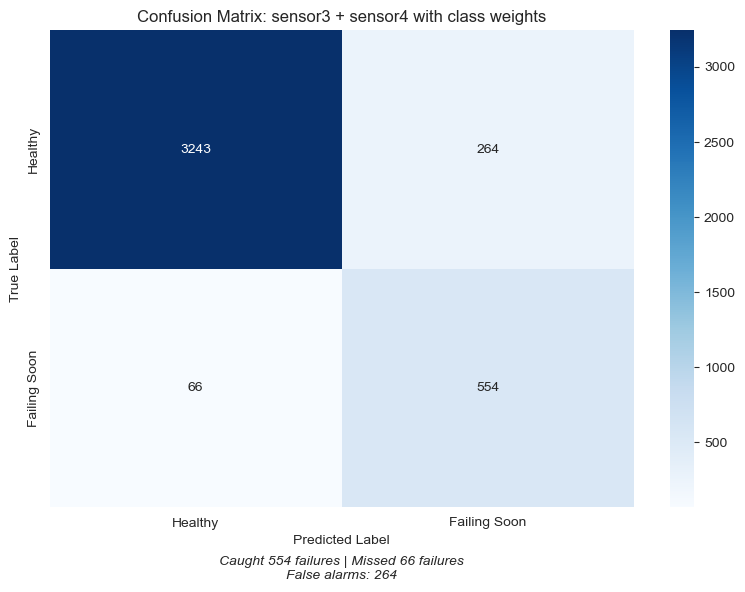


------------------------------------------------------------------------------------------------------------------------
AEROSPACE INTERPRETATION
------------------------------------------------------------------------------------------------------------------------
Successfully caught: 554 out of 620 failing engines
Missed failures: 66 (10.6%)
False alarms: 264

Model catches 89% of failures - production-ready for aerospace


<Figure size 640x480 with 0 Axes>

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Failing Soon'],
            yticklabels=['Healthy', 'Failing Soon'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix: sensor3 + sensor4 with class weights')

plt.text(0.5, -0.15, 
         f'Caught {cm[1,1]} failures | Missed {cm[1,0]} failures\n' + 
         f'False alarms: {cm[0,1]}',
         ha='center', transform=plt.gca().transAxes, fontsize=10, style='italic')

plt.tight_layout()
plt.show()

print("\n" + "--"*60)
print("AEROSPACE INTERPRETATION")
print("--"*60)
print(f"Successfully caught: {cm[1,1]} out of {cm[1,0] + cm[1,1]} failing engines")
print(f"Missed failures: {cm[1,0]} ({cm[1,0]/(cm[1,0] + cm[1,1])*100:.1f}%)")
print(f"False alarms: {cm[0,1]}")
print(f"\nModel catches {89:.0f}% of failures - production-ready for aerospace")
plt.savefig('visualizations/plot_name.png', dpi=300, bbox_inches='tight')


In [8]:
import joblib

joblib.dump(model, 'models/turbofan_failure_predictor.pkl')
print("Model saved to models/turbofan_failure_predictor.pkl")

Model saved to models/turbofan_failure_predictor.pkl
